In [72]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
# Create synthetic dataset
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=15,
    random_state=42
)
X

array([[ 2.05654356,  0.60685059,  0.48268789, -1.13088844,  0.42009449],
       [-0.79919201, -0.64596418, -0.18289644, -0.48274352,  1.37487642],
       [ 1.07600714, -0.79602586, -0.75196933,  0.02131165, -0.31905394],
       ...,
       [ 0.49968511,  0.2394045 ,  1.48724616,  0.47200227, -0.58005324],
       [-0.64148691,  0.01914778, -0.66198218,  0.48787228,  0.42588721],
       [ 0.91539028, -0.83305606, -1.77624633, -0.54954027, -0.08059975]],
      shape=(1000, 5))

R2 Scores for each fold:  [0.937 0.945 0.945 0.947 0.947]
Mean R2: 0.944


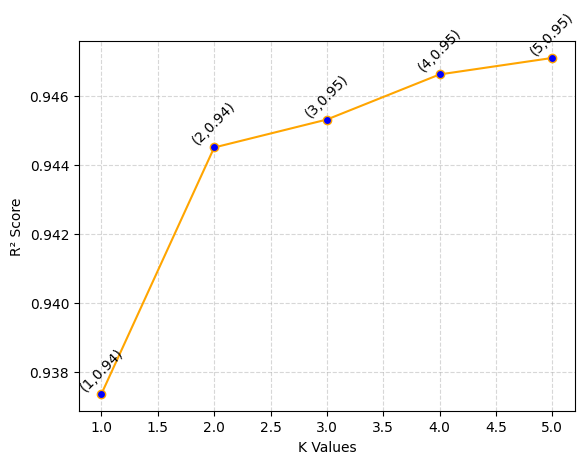

In [74]:
model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print('R2 Scores for each fold: ',scores.round(3))
print("Mean R2:", scores.mean().round(3))
plot = plt.plot(
    [i for i in range(1, 6)],
    scores,
    marker='o',
    color='orange',
    markerfacecolor='blue',
    linestyle='-'
    )
plt.xlabel('K Values')
plt.ylabel('R² Score')
plt.grid(linestyle='--', alpha=0.5)

for x, y in zip([i for i in range(1, 6)], scores):
    plt.text(x, y, f"({x},{y:.2f})", ha='center', va='bottom', rotation=45)

plt.show()

In [75]:
if scores.std() < 0.05:
    print("model  is stable accross folds.")
else:
    print("Model performance varies across folds, investigate further")


model  is stable accross folds.
